Spectral norm of W: 22.633379533446586
default value of tau: 0.4374070600181571
default value of gamma: 0.1


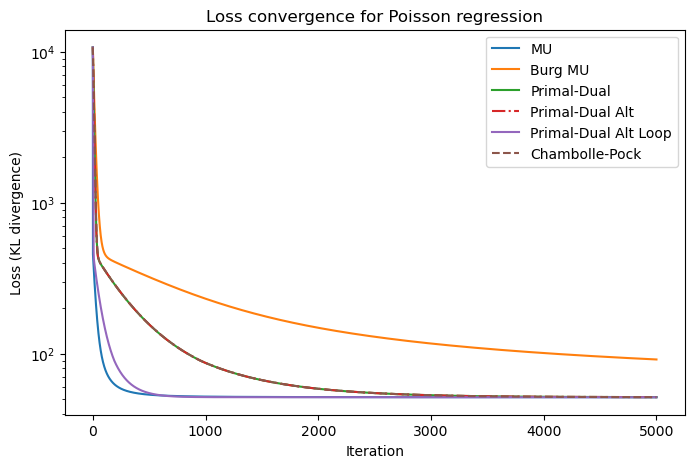

Final loss MU: 51.424123505696315, Burg MU: 91.47066809097116, Primal-Dual: 51.49630561569438, Primal-Dual Alt: 51.49601359972414, Primal-Dual Alt Loop: 51.415618447639424, Chambolle-Pock: 51.49642344212842
Estimation error MU: 0.06775143490588774, Burg MU: 0.25068663304625766, Primal-Dual: 0.0717164548008365, Primal-Dual Alt: 0.07170556104841204, Chambolle-Pock: 0.07172060918184778


In [ ]:
from matplotlib.pylab import f
import numpy as np

# Let's compare MU and Bregman mirror descent on a simple Poisson regression problem

# Hyperparameters
m, n = 100, 20  # number of samples and features
alpha = 100 # Poisson signal level

hgt = np.maximum(np.random.randn(n),0)
W = np.random.rand(m,n)
#W = 0.5*W*np.ones(n) + 0.5*W 
y = np.random.poisson(alpha * W @ hgt)

# Petit check norme spectrale
nW = np.linalg.norm(W, 2)
print(f'Spectral norm of W: {nW}')
gamma = 1e-1
tau = 0.99/nW/gamma
print("default value of tau:", tau)
print("default value of gamma:", gamma)

# Bach Heuristic
#alpha = np.sum(y)/np.sum(W)
#tau = np.sqrt(m/n)/alpha/nW
#gamma = np.sqrt(n/m)*alpha/nW
#print(f"Using tau={tau} and gamma={gamma} from Yanez-Bach heuristic")
        
def loss(h):  # KL divergence
    return np.sum(W@h-y) + np.sum(y * np.log((y+1e-10)/(W @ h)))

def MU(y, W, h, itermax=1000, epsilon=1e-10):
    Wtsum = W.T @ np.ones_like(y)  # suboptimal but ok
    hout = np.copy(h)
    loss_val = [loss(hout)]
    for i in range(itermax):
        hout = np.maximum(epsilon, hout * (W.T @ (y / (W @ hout ))) / (Wtsum))
        loss_val.append(loss(hout))
    return hout, loss_val

def BurgMU(y, W, h, itermax=1000, epsilon=1e-10):  # NoLIPS by Bauschke et al
    Wtsum = W.T @ np.ones_like(y)  # suboptimal but ok
    lamb = 1/2/np.sum(y)
    hout = np.copy(h)
    loss_val = [loss(hout)]
    for i in range(itermax):
        hout = np.maximum(epsilon, hout / ( 1 + lamb* hout * ( Wtsum - W.T @ (y / (W @ hout )))))
        loss_val.append(loss(hout))
    return hout, loss_val

def prox_kl(y, x, tau):
    return 0.5 * (x - tau + np.sqrt((x - tau)**2 + 4 * tau * y))

def prox_kl_dual(y, x, tau):
    return 0.5 * (x - np.sqrt(x**2 + 4 * tau * y))


# Condat-Vu setting
# min eta_+(h) + KL(y, Wh) 
# L = W
# f = eta_+
# g = KL(y, .)
# use prox_tau*g* = Id - tau*prox_kl(y, ./tau, 1/tau)

def CondatVu(y, W, h, itermax=1000, epsilon=1e-10, tau=None, gamma=1e-3):
    hout = np.copy(h)
    if tau is None:
        tau = 0.99/gamma/nW
        print(f"Using tau={tau}")
    u = np.zeros_like(W@h)  # dual variable
    loss_val = [loss(hout)]
    for i in range(itermax):
        uold = np.copy(u)
        utilde = u + tau*W@hout
        u = utilde - tau*prox_kl(y, utilde/tau, 1/tau)
        hout = np.maximum(epsilon, hout - gamma*W.T@(2*u - uold))
        loss_val.append(loss(hout))
    return hout, loss_val

def CondatVuAlt(y, W, h, itermax=1000, epsilon=1e-10, tau=None, gamma=1e-3):
    hout = np.copy(h)
    if tau is None:
        tau = 0.99/gamma/nW
        print(f"Using tau={tau}")
    u = np.zeros_like(W@h)  # dual variable
    loss_val = [loss(hout)]
    for i in range(itermax):
        utilde = u + tau*W@hout
        u = utilde - tau*prox_kl(y, utilde/tau, 1/tau)
        hout = np.maximum(epsilon, hout - gamma*W.T@u)
        loss_val.append(loss(hout))
    return hout, loss_val

def CondatVuAltLoop(y, W, h, itermax=1000, epsilon=1e-10, tau=None, gamma=1e-3):
    hout = np.copy(h)
    if tau is None:
        tau = 0.99/gamma/nW
        print(f"Using tau={tau}")
    u = np.zeros_like(W@h)  # dual variable
    loss_val = [loss(hout)]
    for i in range(itermax):
        Wh = W@hout
        for _ in range(5):  # inner loop
            utilde = u + tau*Wh
            u = utilde - tau*prox_kl(y, utilde/tau, 1/tau)
        Wtu = W.T@u
        for _ in range(5):
            hout = np.maximum(epsilon, hout - gamma*Wtu)
        loss_val.append(loss(hout))
    return hout, loss_val

def ChambollePockBach(y, W, hinit=None, itermax=1000, epsilon=1e-10, gamma=None, tau=None):
    hout = np.copy(hinit)
    if tau is None and gamma is None:
        # Bach Heuristic
        alpha = np.sum(y)/np.sum(W)
        tau = np.sqrt(m/n)/alpha/nW
        gamma = np.sqrt(n/m)*alpha/nW
        print(f"Using tau={tau} and gamma={gamma}")
    loss_val = [loss(hout)]
    u = np.zeros_like(W@hout) # W@hout
    htilde = np.copy(hout)
    hold = np.copy(hout)
    for i in range(itermax):
        utilde = u + tau*W@htilde
        u = (utilde - np.sqrt(utilde**2 + 4*tau*y))/2
        hout = np.maximum(epsilon, hout - gamma*W.T@(u + 1))
        htilde = 2*hout - hold
        hold = np.copy(hout)
        loss_val.append(loss(hout))
    return hout, loss_val


hmu, loss_mu = MU(y, W, alpha*np.ones(n), itermax=5000)
hburg, loss_burg = BurgMU(y, W, alpha*np.ones(n), itermax=5000)
hpd, loss_pd = CondatVu(y, W, alpha*np.ones(n), itermax=5000, tau=tau, gamma=gamma)
hpda, loss_pda = CondatVuAlt(y, W, alpha*np.ones(n), itermax=5000, tau=tau, gamma=gamma)
hpdal, loss_pdal = CondatVuAltLoop(y, W, alpha*np.ones(n), itermax=5000, tau=tau, gamma=gamma)
#hcp, loss_cp = ChambollePockBach(y, W, alpha*np.ones(n), itermax=5000, tau=None, gamma=None)  # very fast !
hcp, loss_cp = ChambollePockBach(y, W, alpha*np.ones(n), itermax=5000, tau=tau, gamma=gamma)  # very fast !

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.semilogy(loss_mu, label='MU')
plt.semilogy(loss_burg, label='Burg MU')
plt.semilogy(loss_pd, label='Primal-Dual')
plt.semilogy(loss_pda, label='Primal-Dual Alt', linestyle='-.')
plt.semilogy(loss_pdal, label='Primal-Dual Alt Loop')
plt.semilogy(loss_cp, label='Chambolle-Pock', linestyle='--')
plt.title('Loss convergence for Poisson regression')
plt.xlabel('Iteration')
plt.ylabel('Loss (KL divergence)')
plt.legend()
plt.show()

# Printing the final estimation error
print(f"Final loss MU: {loss_mu[-1]}, Burg MU: {loss_burg[-1]}, Primal-Dual: {loss_pd[-1]}, Primal-Dual Alt: {loss_pda[-1]}, Primal-Dual Alt Loop: {loss_pdal[-1]}, Chambolle-Pock: {loss_cp[-1]}")
print(f"Estimation error MU: {np.linalg.norm(hmu - alpha*hgt)/np.linalg.norm(alpha*hgt)}, Burg MU: {np.linalg.norm(hburg - alpha*hgt)/np.linalg.norm(alpha*hgt)}, Primal-Dual: {np.linalg.norm(hpd - alpha*hgt)/np.linalg.norm(alpha*hgt)}, Primal-Dual Alt: {np.linalg.norm(hpda - alpha*hgt)/np.linalg.norm(alpha*hgt)}, Chambolle-Pock: {np.linalg.norm(hcp - alpha*hgt)/np.linalg.norm(alpha*hgt)}")